# QC testing: Setting Hard QC thresholds

+ Plate 1: 96 samples(60/36), on MEGA kit v2, seq 15 sub-lib X 3 runs
+ Plate 2: 96 samples (88/8), on MEGA kit v2, seq 16 sub-lib X 3 runs
+ ~30 Billion reads per plate
+ Parse workflow has a low [doublet rate](https://support.parsebiosciences.com/hc/en-us/articles/360053107311-What-is-the-expected-doublet-rate#:~:text=Doublet%20rates%20are%20low%2C%20less,through%20the%20Whole%20Transcriptome%20workflow.): ~3% per 100K cells

***

Testing different filtering thresholds:

- Filter 1: Hard threshold for genes
    - min_genes_per_cell=500, 
    - max_genes_per_cell=6000,
    - min_counts_per_cell=500, 
    - min_cells_per_gene=5, 
    - min_cells_per_sample=10
    - Mito - 5%
    - Ribo - 5%
    - Filtering MT genes and MALAT1 removed
    - rm_doublets = False
    - rm_mad_outliers = False

- Filter 2: MAD thresholds per sample and doublet removal
    - Done in initial QC run
 
- Filter 3: Retain genes with at least `min_reads` in at least `min_samples` in the dataset
    - Discussed 100 samples, but indivdual plates have < 100 samples so applied n samples
 
***

In [1]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [2]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??
rm_doublets = False
rm_mad_outliers = False
run_filter_1 = True
run_filter_2 = False
run_filter_3 = False

# Load data

2025-01-14 11:01:50,055 - INFO - Plate variable detected: plate1
2025-01-14 11:01:50,056 - INFO - Processing plate: plate1



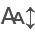

2025-01-14 11:01:50,078 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-14 11:01:50,079 - INFO - Data directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-14 11:01:50,080 - INFO - Saving to directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-14 11:01:50,080 - INFO - Directory exists: True
2025-01-14 11:01:50,082 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-14 11:01:50,082 - INFO - Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-14 11:01:50,083 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-14 11:01:50,084 - INFO - Plate path directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-14 11:01:50,085 - INFO - Loading data ...


Processing 1 plate(s) with downsampling to 4000 cells per plate.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad ...
Plate 1 dimensions: (861960, 65472)
Plate 1 matrix dimensions: (861960, 65472)
Only one plate processed; no need to find common genes.
AnnData object with n_obs × n_vars = 4000 × 65472
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden'
    var: 'gene_id', 'gene_name', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm10k'
    obsp: 'connectivities', 'distances'


In [3]:
# Initialize the environment and get all paths and logger
logger, root_dir, plate_path, scanpy_dir = initialize_env(plate)

# Log the directories in the notebook
logger.info("Root directory: %s", root_dir)
logger.info("Scanpy directory: %s", scanpy_dir)
logger.info("Plate path directory: %s", plate_path)
logger.info("Loading data ...")

# Use the plate_path and scanpy_dir as needed
adata = load_and_dwnsmpl_data(None, plate_path)

In [4]:
adata.obs

sample species  gene_count  tscp_count  \
bc_wells                                                             
plate1_04_42_96__s12  sample_17671    hg38        2691        6422   
plate1_60_82_35__s2   sample_11928    hg38         702         900   
plate1_16_60_57__s9       14510_FC    hg38        1202        2063   
plate1_44_20_16__s1   sample_17048    hg38       10118       52961   
plate1_88_75_14__s2   sample_17629    hg38        5644       18174   
...                            ...     ...         ...         ...   
plate1_86_50_71__s10  sample_17264    hg38         991        1441   
plate1_71_70_67__s7       12972_FC    hg38        2552        5206   
plate1_44_51_49__s3   sample_17048    hg38        2181        4235   
plate1_89_89_35__s9   sample_17630    hg38        2592        5365   
plate1_35_72_74__s12     16114_WGE    hg38         175         185   

                      mread_count leiden  
bc_wells                                  
plate1_04_42_96__s12        14646      2  
plate1_60_82_35__s2          2458      2  
plate1_16_60_57__s9          4167      2  
plate1_44_20_16__s1         92005     21  
plate1_88_75_14__s2         52602     10  
...                           ...    ...  
plate1_86_50_71__s10         2899      2  
plate1_71_70_67__s7          9823      0  
plate1_44_51_49__s3          8715      3  
plate1_89_89_35__s9         10446      9  
plate1_35_72_74__s12          403      9  

[4000 rows x 6 columns]

# QC metadata

In [5]:
logger.info("Running QC ...")
adata.obs['sample'] = adata.obs['sample'].str.replace('sample_', '')
adata = adata[~adata.obs['sample'].str.endswith(tuple(['WGE', 'Hipp', 'Thal']))]
adata.obs['sublibrary'] = [x[1] for x in adata.obs.index.str.split('__s')] 
adata.obs['sample'].value_counts() # Cells per sample pre-filter

2025-01-14 11:03:09,523 - INFO - Running QC ...


sample
11654       101
17486        94
18372        94
17048        91
17053        84
           ... 
12047        21
14402        17
14521        15
17940        15
14611_FC     11
Name: count, Length: 73, dtype: int64

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

#plt.hist(adata.var['n_cells_by_counts'], bins=500)
#plt.xlabel('N cells expressing > 0')
#plt.ylabel('log(N genes)') # for visual clarity
#plt.axvline(2, color='red')
#plt.yscale('log') 

#sns.jointplot(
#   data=adata.obs,
#   x="log1p_total_counts",
#   y="log1p_n_genes_by_counts",
#   kind="hex",
#)
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate1_04_42_96__s12     17671    hg38        2691        6422        14646   
plate1_60_82_35__s2      11928    hg38         702         900         2458   
plate1_16_60_57__s9   14510_FC    hg38        1202        2063         4167   
plate1_44_20_16__s1      17048    hg38       10118       52961        92005   
plate1_88_75_14__s2      17629    hg38        5644       18174        52602   
...                        ...     ...         ...         ...          ...   
plate1_90_29_26__s8   18190_FC    hg38         948        1411         3542   
plate1_86_50_71__s10     17264    hg38         991        1441         2899   
plate1_71_70_67__s7   12972_FC    hg38        2552        5206         9823   
plate1_44_51_49__s3      17048    hg38        2181        4235         8715   
plate1_89_89_35__s9      17630    hg38        2592        5365        10446   

                     leiden sublibrary  n_genes_by_counts  \
bc_wells                                                    
plate1_04_42_96__s12      2         12               2691   
plate1_60_82_35__s2       2          2                702   
plate1_16_60_57__s9       2          9               1202   
plate1_44_20_16__s1      21          1              10118   
plate1_88_75_14__s2      10          2               5644   
...                     ...        ...                ...   
plate1_90_29_26__s8       2          8                948   
plate1_86_50_71__s10      2         10                991   
plate1_71_70_67__s7       0          7               2552   
plate1_44_51_49__s3       3          3               2181   
plate1_89_89_35__s9       9          9               2592   

                      log1p_n_genes_by_counts  total_counts  ...  \
bc_wells                                                     ...   
plate1_04_42_96__s12                 7.898040   6586.567259  ...   
plate1_60_82_35__s2                  6.555357   3034.552107  ...   
plate1_16_60_57__s9                  7.092574   4025.412832  ...   
plate1_44_20_16__s1                  9.222170  12260.958536  ...   
plate1_88_75_14__s2                  8.638525   9106.075445  ...   
...                                       ...           ...  ...   
plate1_90_29_26__s8                  6.855409   3581.779470  ...   
plate1_86_50_71__s10                 6.899723   3795.181586  ...   
plate1_71_70_67__s7                  7.845024   6565.129726  ...   
plate1_44_51_49__s3                  7.687997   6110.983897  ...   
plate1_89_89_35__s9                  7.860571   6847.297919  ...   

                      pct_counts_in_top_500_genes  total_counts_mt  \
bc_wells                                                             
plate1_04_42_96__s12                    39.257641         0.000000   
plate1_60_82_35__s2                     84.087342         0.000000   
plate1_16_60_57__s9                     60.235799         2.179794   
plate1_44_20_16__s1                     16.560762         2.119621   
plate1_88_75_14__s2                     23.443868         7.263694   
...                                           ...              ...   
plate1_90_29_26__s8                     70.736005         2.873311   
plate1_86_50_71__s10                    69.581517         0.000000   
plate1_71_70_67__s7                     37.939682         1.323045   
plate1_44_51_49__s3                     43.179147         0.000000   
plate1_89_89_35__s9                     40.128878         0.000000   

                      log1p_total_counts_mt  pct_counts_mt  total_counts_ribo  \
bc_wells                                                                        
plate1_04_42_96__s12               0.000000       0.000000          37.962656   
plate1_60_82_35__s2                0.000000       0.000000          24.618447   
plate1_16_60_57__s9                1.156816       0.054151           0.000000   
p

In [7]:
adata.obs[['tscp_count', 'total_counts']] # Why the discrepancy? Duplicates? This is the filtered matrix??!!

tscp_count  total_counts
bc_wells                                      
plate1_04_42_96__s12        6422   6586.567259
plate1_60_82_35__s2          900   3034.552107
plate1_16_60_57__s9         2063   4025.412832
plate1_44_20_16__s1        52961  12260.958536
plate1_88_75_14__s2        18174   9106.075445
...                          ...           ...
plate1_90_29_26__s8         1411   3581.779470
plate1_86_50_71__s10        1441   3795.181586
plate1_71_70_67__s7         5206   6565.129726
plate1_44_51_49__s3         4235   6110.983897
plate1_89_89_35__s9         5365   6847.297919

[3187 rows x 2 columns]

2025-01-14 11:03:10,282 - INFO - Most exp genes ...


normalizing counts per cell
    finished (0:00:00)


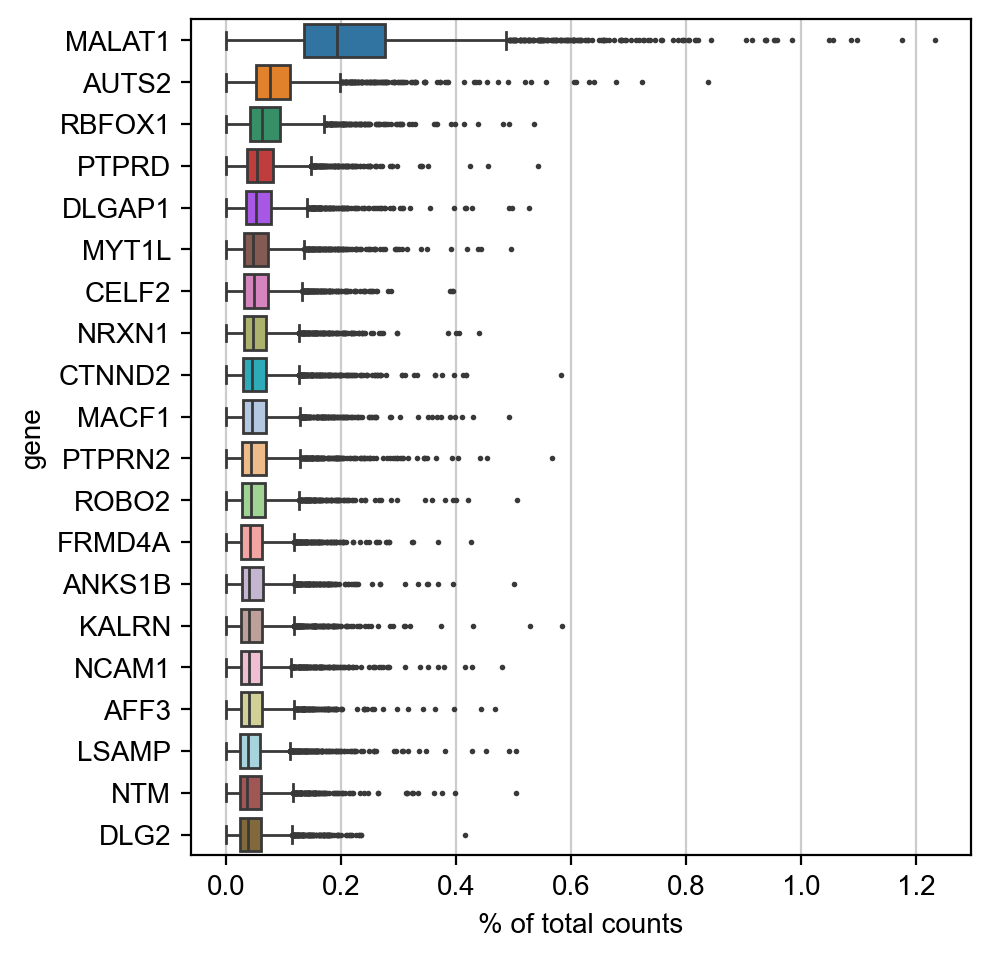

In [8]:
# Most expressed genes - Not such a big deal now?
logger.info("Most exp genes ...")
sc.pl.highest_expr_genes(adata, n_top=20)

In [9]:
# Filter 1
# - Remove cells with < 300 genes OR < 500 reads
# - Remove genes expressed in < 5 cells
# - Remove samples with fewer than 500 cells

#### NOTE: tscp_count != total_counts. Scanpy uses total_counts for filters. Check why these values don't match ####

2025-01-14 11:03:10,880 - INFO - Applying filter 1 ...
... storing 'sample' as categorical
... storing 'sublibrary' as categorical


Dimensions before applying filter: (3187, 65472)
filtered out 271 cells that have less than 500 genes expressed
filtered out 246 cells that have more than 6000 genes expressed
filtered out 40066 genes that are detected in less than 5 cells
filtered out 0 samples with < 10 cells.
Dimensions after applying filter: (2670, 25406)


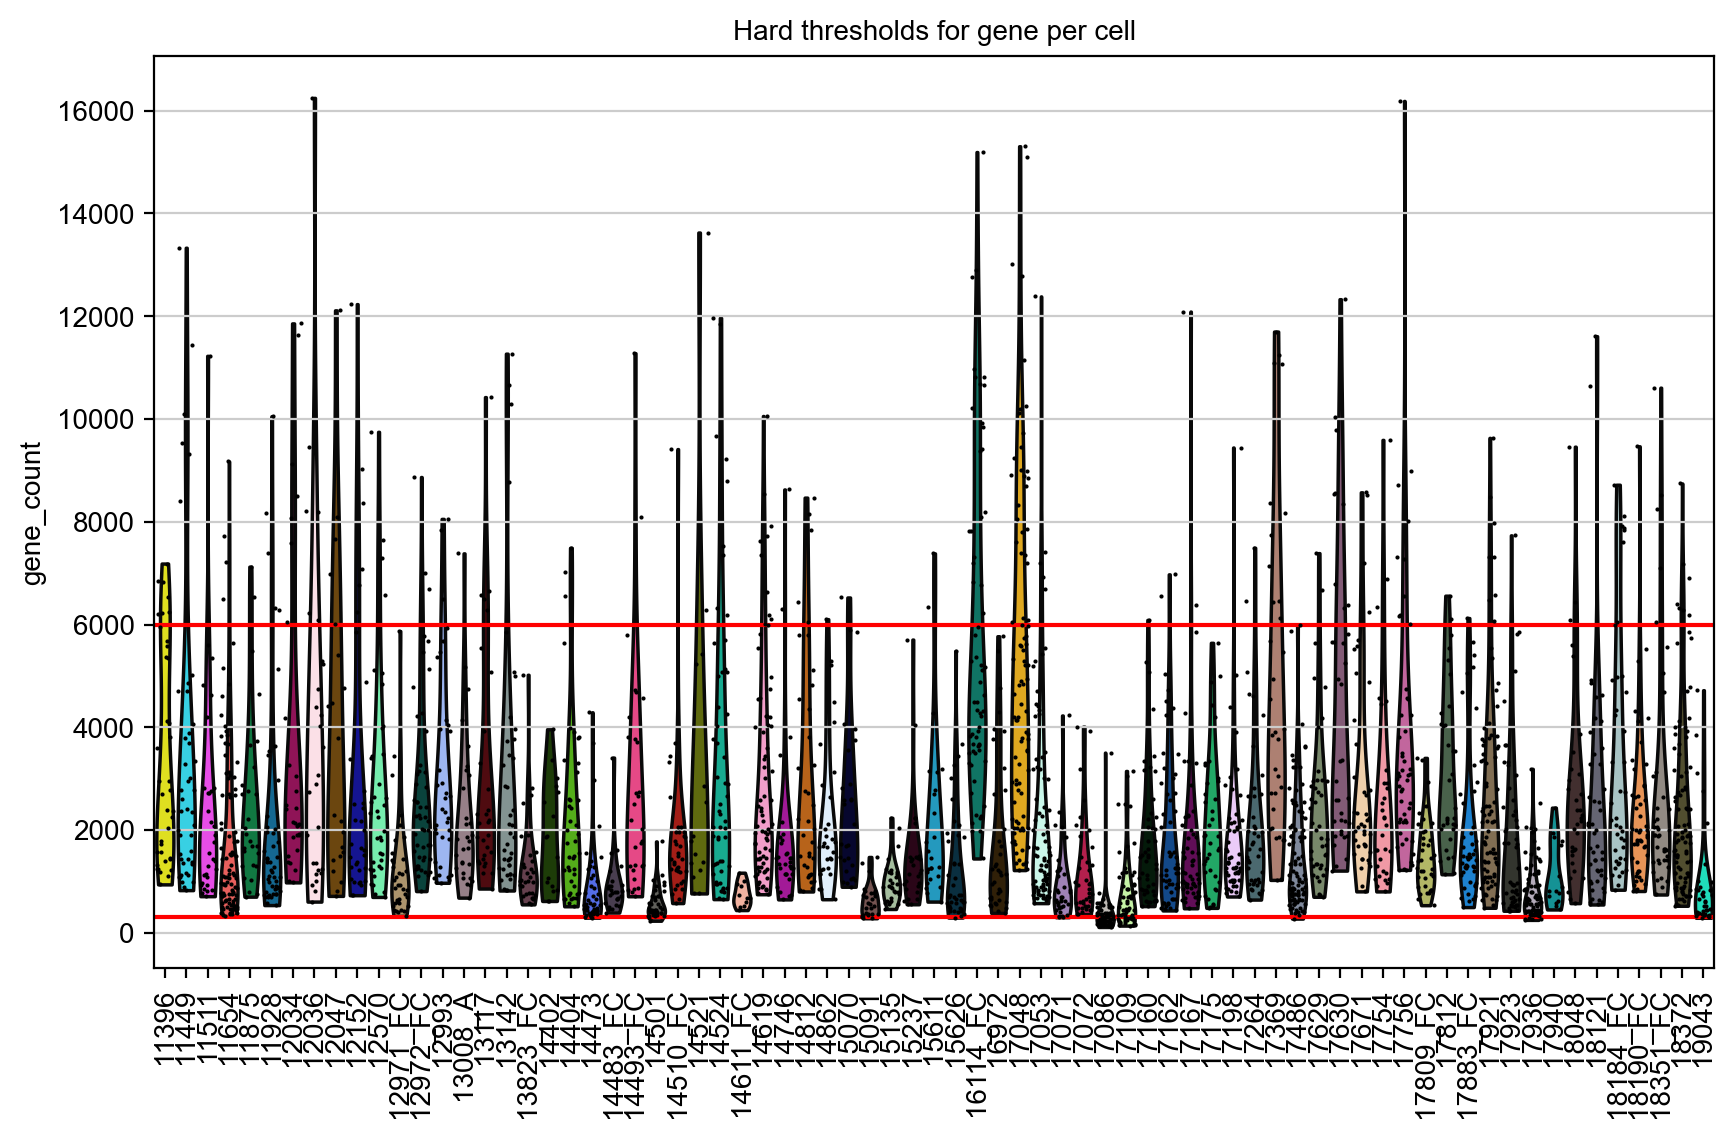

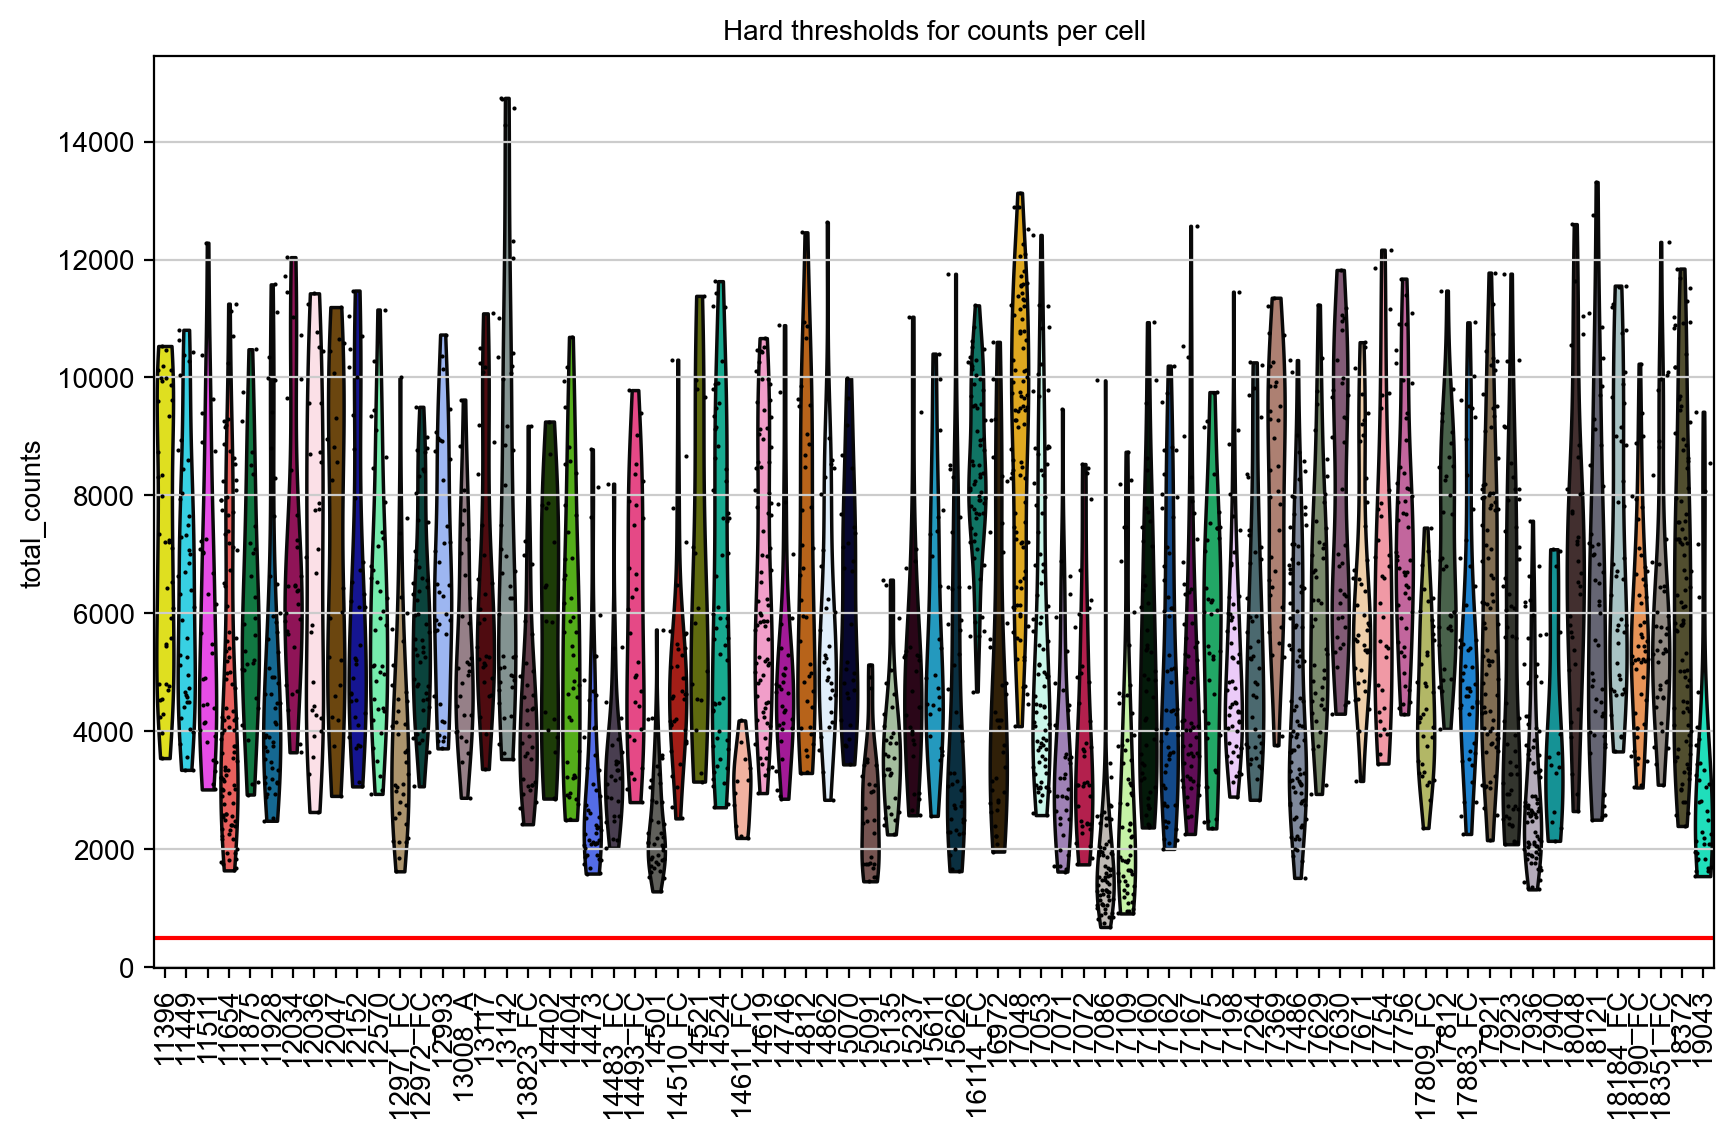

In [10]:
if run_filter_1 is True:
    logger.info("Applying filter 1 ...")

    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')
    
    # 
    
    filter_anndata(
        adata, 
        min_genes_per_cell=500, 
        max_genes_per_cell=6000,
        min_counts_per_cell=500, 
        min_cells_per_gene=5, 
        min_cells_per_sample=10)
    adata.shape

In [11]:
#Filter 2 
if run_filter_2 is True:
    logger.info("Detecting MAD outliers ...")
    detect_mad_outliers_per_sample(
        adata,
        group_column="sample",       # Column in `adata.obs` to group by
        target_column="total_counts",  # Column to detect outliers
        threshold=3,                # Number of MADs for outlier detection
        log=False,                  # Whether to log-transform the data
        use_median=True             # Use median and MAD (or mean and SD)
    )
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    
    # Overlay outlier cells with red dots
    outliers = adata.obs.loc[adata.obs['mad_outlier']]
    ax.scatter(
        x=outliers['sample'],  # X-coordinates (groupby value)
        y=outliers['total_counts'],  # Y-coordinates (outlier values)
        color='red',
        label='Outliers',
        s=10,
        alpha=0.8
    )


In [12]:
# Note this function includes mito and ribo gene removal so is always run
logger.info("Applying filter 2 ...") 
filter_cells_and_genes(adata, 5, 5, rm_doublets, rm_mad_outliers)

2025-01-14 11:03:16,222 - INFO - Applying filter 2 ...


Applying cell filters with thresholds: mito > 5%, ribo > 5%
Counts of outliers for removal:
  mito_gt_threshold: 0
  ribo_gt_threshold: 0
  is_outlier: 0
Dimensions before cell filter: (2670, 25406)
Dimensions after cell filter: (2670, 25406)
Applying gene filters: remove mitochondrial genes and MALAT1
Number of genes removed: 12
Dimensions after gene filter: (2670, 25394)


In [13]:
# Filter 3
if run_filter_3 is True:
    sample_num = adata.obs['sample'].nunique() # Note that the maximum number of samples will be < 100 per plate
    def filter_genes_by_read_count(adata, min_reads=10, min_samples=100, inplace=True):
        """
        Identifies genes with at least `min_reads` in at least `min_samples` in the dataset.
        
        Parameters:
        - adata: AnnData object containing gene expression data.
        - min_reads: Minimum number of reads required per cell/sample.
        - min_samples: Minimum number of samples/cells that must meet the `min_reads` threshold.
        - inplace: If True, filters genes directly in `adata`. If False, returns a mask.
    
        Returns:
        - If `inplace=True`: Modifies `adata` by retaining only the filtered genes.
        - If `inplace=False`: Returns a boolean mask of the genes that meet the criteria.
        """
        # Count the number of samples with at least `min_reads` for each gene
        gene_mask = (adata.X >= min_reads).sum(axis=0).A1 >= min_samples
    
        if inplace:
            # Subset the AnnData object to retain only the filtered genes
            adata._inplace_subset_var(gene_mask)
        else:
            # Return the mask for external usage
            return gene_mask
    
    filter_genes_by_read_count(adata, min_reads=10, min_samples=100)
    print(f"Filtered genes: {adata.n_vars} remain.")
    
    #gene_mask = filter_genes_by_read_count(adata, min_reads=10, min_samples=sample_num, inplace=False)
    #print(f"Number of genes meeting criteria: {gene_mask.sum()}")
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:00)
    computed connectivities (0:00:04)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
running Leiden clus

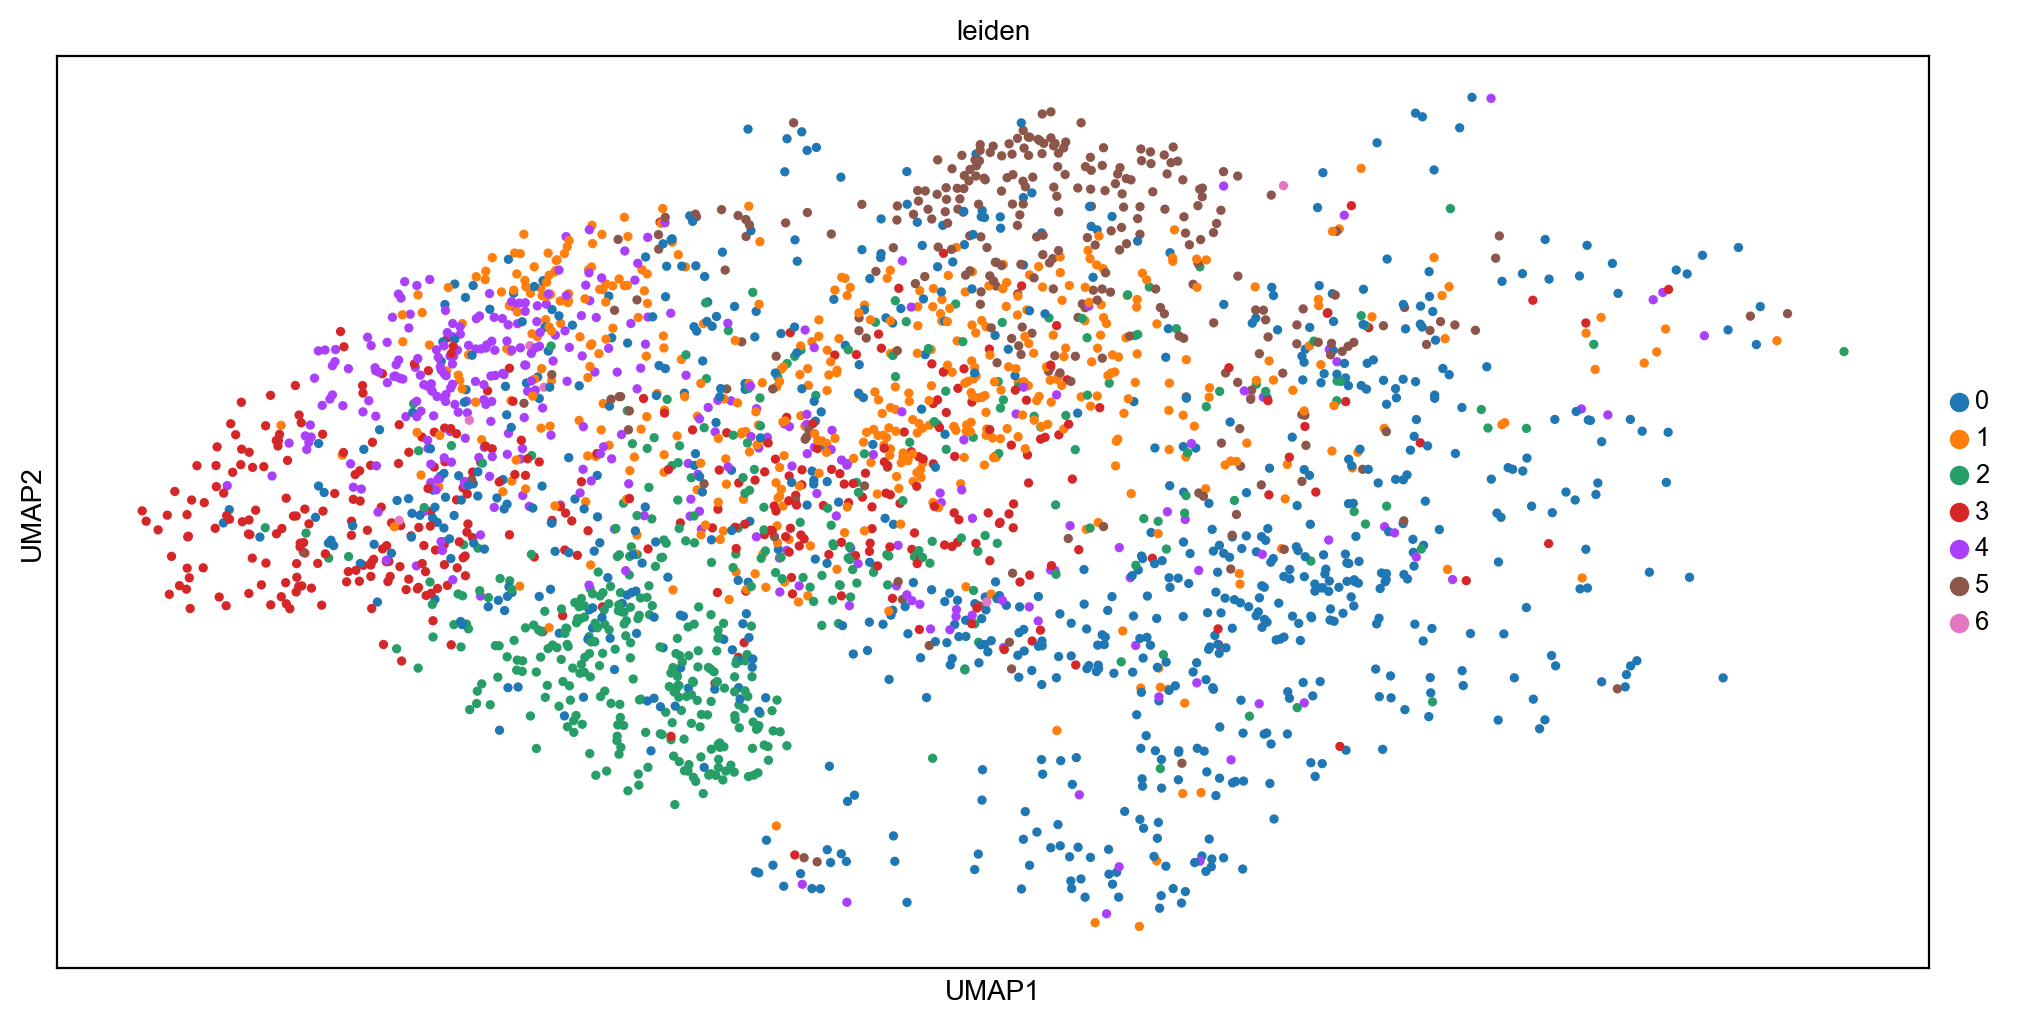

In [14]:
# Plot UMAP
def run_default_scanpy(ann_obj):

    sc.pp.normalize_total(ann_obj) # Norm to median total count
    sc.pp.log1p(ann_obj)
    sc.pp.highly_variable_genes(ann_obj, n_top_genes=2000, flavor="seurat_v3")
    sc.tl.pca(ann_obj, svd_solver='arpack')
    sc.pp.neighbors(ann_obj)
    sc.tl.leiden(ann_obj)
    sc.pl.umap(ann_obj, color=['leiden'])

run_default_scanpy(adata)

In [15]:
# Final Dimesnsions
adata.shape

(2670, 25394)

In [16]:
# Cells per sample after filter
adata.obs['sample'].value_counts()

sample
18372       87
17486       84
11654       81
17053       79
17921       74
            ..
15091       15
17940       14
14521       13
17086       12
14611_FC    10
Name: count, Length: 73, dtype: int64

In [17]:
# Save
logger.info("Saving h5ad file ...")
adata.write(scanpy_dir + f'adata_qc_testing_{plate}.h5ad')
logger.info(f"{plate} qc run done.")